In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system_alt import BatHeadDirectionSystem
from grid_cells.plot_tools import angular_error, smooth_ts
import os

DATA_DIR = "../simulation_data/resetting"
PLOTS_DIR = "../plots/resetting"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
T = 20
dt = 0.5e-3
n = 256
intrinsic_noise = 0.01
input_noise = 0  # 1
n_conj = 200
interval = 100

net_anchor = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    # anchor_strength=1,
    # forward_strength=-1,
    feedback_strength=3,
)
bat_flight = generate_bat_flight(T=T, dt=dt)

100%|██████████| 39999/39999 [00:02<00:00, 14408.49it/s]


In [3]:
net_anchor.warm_up(
    initial_dir=bat_flight["dir_sphere"][0] * 0
    + 1 * np.pi * np.array([1, 0], dtype=float)
)

Ran warm up for 140 steps


In [4]:
recording_anchor = net_anchor.run_simulation(
    bat_flight["dir_vel"],
    dir=bat_flight["dir_sphere"],
    inverted=bat_flight["inverted"],
    save_weights=True,
    interval=interval,
)

Running Simulation Steps: 100%|██████████| 40000/40000 [00:09<00:00, 4232.13it/s]


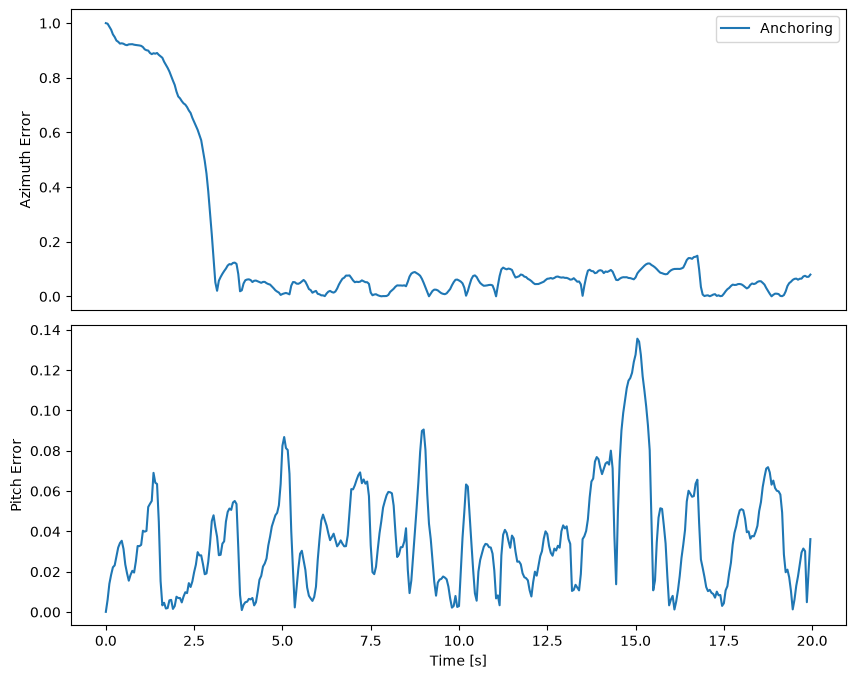

In [5]:
smooth_interval = 1
fig, ax = plt.subplots(
    nrows=2,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"hspace": (0.05)},
)
for angle_iter, angle in enumerate(["Azimuth", "Pitch"]):
    simple_anchor_error = angular_error(
        recording_anchor["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][::interval, angle_iter],
    )
    ax[1 * angle_iter].plot(
        smooth_ts(bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(simple_anchor_error, smooth_interval)),
        label="Anchoring",
    )
    ax[1 * angle_iter].set_ylabel(angle + " Error")


for axis_iter in range(len(ax) - 1):
    ax[axis_iter].get_xaxis().set_visible(False)


ax[0].legend()
ax[-1].set_xlabel("Time [s]")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_anchoring_effect.svg"))

In [6]:
angular_error(
    recording_anchor["anchor_angles"][
        (recording_anchor["visual_trace"][-1] > 0.9 * recording_anchor["visual_trace"][-1].max() )
    ],
    bat_flight["dir_torus"][-1],
)

array([[-0.0217628 ,  0.03163095],
       [-0.0699474 ,  0.00838667]])

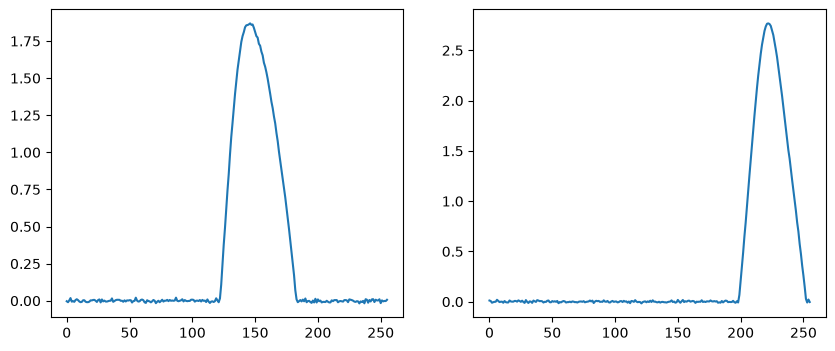

In [7]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
ax[0].plot(net_anchor.yaw_ring.s)
ax[1].plot(net_anchor.pitch_ring.s)